# RL-7b — Sur-généralisation relative dans le Climbing Game

**Série** : Reinforcement Learning | **Niveau** : intermédiaire | **Durée estimée** : 45 min

Navigation : [← RL-7 Multi-Agent](rl_7_multi_agent_rl.ipynb) | **RL-7b Climbing Game**

## Objectifs d’apprentissage
- reconnaître la **sur-généralisation relative** dans un jeu coopératif non dégénéré ;
- implémenter IQL et sa variante **hysteretic** ;
- comparer plusieurs graines avec IQM et bootstrap ;
- distinguer non-stationnarité, exploration et biais de mauvaise coordination.

**Prérequis** : Q-learning tabulaire, politique $\varepsilon$-greedy, équilibres de Nash. Toutes les expériences sont CPU et déterministes par graine.

## Question directrice

Dans un problème mono-agent, une action possède une distribution de récompenses fixée par l'environnement. Ici, la récompense associée à `A` dépend aussi de l'action choisie au même instant par l'autre apprenant. L'expérience cherchera donc moins à répondre « quelle méthode obtient la meilleure courbe ? » qu'à établir la chaîne causale suivante : exploration indépendante → mauvaises coordinations transitoires → estimation marginale pessimiste de `A` → convergence vers un équilibre dominé.

Le notebook suit le *Climbing Game* introduit comme banc d'essai de l'apprentissage coopératif indépendant par Claus et Boutilier (1998). La mise à jour asymétrique étudiée ensuite correspond au principe d'hysteretic Q-learning de Matignon, Laurent et Le Fort-Piat (2007). Ces références motivent le mécanisme ; les nombres affichés ici proviennent exclusivement de l'exécution locale multi-graines.


## 1. Un jeu coopératif qui piège les apprenants indépendants

| Agent 1 \ Agent 2 | A | B | C |
|---|---:|---:|---:|
| **A** | **11** | -30 | 0 |
| **B** | -30 | 7 | 6 |
| **C** | 0 | 0 | 5 |

L’optimum conjoint est `(A,A)` avec 11. Mais une exploration non coordonnée de `A` rencontre souvent -30. Chaque agent peut sous-évaluer `A` et se réfugier dans `(C,C)` : la qualité d’une action est diluée par les actions simultanées de l’autre agent.

### Trois propriétés à ne pas confondre

1. `(A,A)` est le **maximum global** de la matrice, mais `A` n'est pas individuellement sûre : `(A,B)` et `(B,A)` valent -30.
2. `(B,B)` et `(C,C)` sont des coordinations localement stables sous une réponse symétrique, tout en étant dominées par `(A,A)`.
3. Le jeu est pleinement coopératif : les deux agents reçoivent exactement la même récompense. L'échec ne vient donc ni d'intérêts opposés ni d'un problème d'attribution entre récompenses différentes.

La sur-généralisation est dite **relative** parce qu'un agent évalue une action en moyenne relativement à la politique courante de son partenaire. Au début, cette politique explore presque uniformément. Pour `A`, la moyenne uniforme vaut $(11-30+0)/3=-6{,}33$, alors que pour `C` elle vaut $(0+0+5)/3=1{,}67$. Une action indispensable à l'optimum paraît ainsi moins bonne quand on marginalise sur un partenaire encore mal coordonné. Ce calcul ne prédit pas à lui seul la trajectoire stochastique, mais rend le piège falsifiable avant la simulation.


In [1]:
from collections import Counter
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np

ACTIONS = np.array(["A", "B", "C"])
PAYOFF = np.array([[11., -30., 0.], [-30., 7., 6.], [0., 0., 5.]])
joint_optimum = np.unravel_index(np.argmax(PAYOFF), PAYOFF.shape)
print(f"Matrice chargée : optimum {tuple(map(str, ACTIONS[list(joint_optimum)]))}, récompense {PAYOFF[joint_optimum]:.0f}")

Matrice chargée : optimum ('A', 'A'), récompense 11


### Lecture du résultat

Le maximum imprimé confirme que `(A,A)` domine les autres coordinations. Il faut préserver une action excellente malgré ses résultats catastrophiques lorsqu’elle est mal coordonnée.

Le calcul exhaustif de la matrice sert de garde-fou : il sépare la qualité normative de l'optimum de ce que les agents apprendront effectivement. Si IQL converge vers une autre paire, on pourra parler d'un défaut d'apprentissage plutôt que d'une ambiguïté sur l'objectif.

La récompense 11 est commune aux deux agents. Les courbes ultérieures montrent donc le retour d'équipe par épisode, sans somme supplémentaire qui doublerait artificiellement l'échelle.


## 2. Même agent tabulaire, deux règles de mise à jour

Chaque agent possède sa propre table Q et choisit par $\varepsilon$-greedy. IQL utilise $\alpha^+=\alpha^-$ ; hysteretic Q-learning utilise $\alpha^-<\alpha^+$. La récompense reste identique : ce n’est pas un bonus ad hoc.

### Équation de mise à jour

Le jeu n'a qu'un état et chaque épisode se termine après une action conjointe. La cible de Q-learning se réduit donc à la récompense immédiate :

$$
\delta_t = r_t-Q_t(a_t), \qquad
Q_{t+1}(a_t)=Q_t(a_t)+\alpha(\delta_t)\,\delta_t.
$$

Pour IQL, $\alpha(\delta)=0{,}1$ quel que soit le signe. Pour la variante hysteretic, $\alpha(\delta)=\alpha^+$ si $\delta\geq0$ et $\alpha^-$ sinon, avec $\alpha^-<\alpha^+$. Une mauvaise coordination fait donc toujours baisser la valeur ; elle le fait seulement plus lentement. C'est important : le code ne filtre aucune observation, n'ajoute aucun bonus et ne connaît pas la matrice optimale.

Les tables sont indépendantes et aucune action de l'autre agent n'entre dans l'observation. Du point de vue de chaque table, la dynamique de l'autre politique rend la distribution des récompenses non stationnaire. Le tirage aléatoire entre actions ex æquo évite en outre de favoriser `A` par son indice.


In [2]:
@dataclass
class TabularAgent:
    alpha_positive: float
    alpha_negative: float
    n_actions: int = 3

    def __post_init__(self):
        self.q = np.zeros(self.n_actions)

    def act(self, rng, epsilon):
        if rng.random() < epsilon:
            return int(rng.integers(self.n_actions))
        best = np.flatnonzero(self.q == self.q.max())
        return int(rng.choice(best))

    def update(self, action, reward):
        td_error = reward - self.q[action]
        alpha = self.alpha_positive if td_error >= 0 else self.alpha_negative
        self.q[action] += alpha * td_error

print("Agent tabulaire défini : IQL ou hysteretic selon alpha_negative.")

Agent tabulaire défini : IQL ou hysteretic selon alpha_negative.


### Exercice 1 — Prédire l’effet de l’hystérésis

Proposez une valeur de `alpha_negative` qui protège `A` sans ignorer toutes les observations négatives. **Indice** : comparez les vitesses d’apprentissage positive et négative.

Une hypothèse complète doit aussi annoncer un risque. Quand $\alpha^-$ devient trop petit, l'agent conserve longtemps une estimation optimiste même si les retours négatifs signalent une action réellement mauvaise. L'ablation finale vérifiera donc une plage de valeurs au lieu de ne montrer que le meilleur réglage.

Pour raisonner avant d'exécuter, comparez notamment `0.05` et `0.01` : les deux satisfont $\alpha^-<\alpha^+$, mais la première valeur ne ralentit les corrections négatives que d'un facteur deux, contre dix pour la seconde.


In [3]:
hypothese_alpha_negative = None  # TODO étudiant
print("Exercice 1 à compléter :", hypothese_alpha_negative)

Exercice 1 à compléter : None


## 3. Protocole expérimental multi-graines

Chaque condition emploie 12 000 épisodes, le même calendrier d’exploration et les graines 0 à 19. Les 1 000 derniers épisodes déterminent l’équilibre empirique dominant.

### Contrôles expérimentaux

- **Même budget** : chaque couple méthode–graine reçoit exactement 12 000 interactions.
- **Même exploration** : $\varepsilon_0=1$, décroissance multiplicative `0.9995`, plancher `0.02`.
- **Mêmes graines** : la comparaison est appariée sur `0, …, 19` ; seule la règle de mise à jour change.
- **Fenêtre terminale** : les 1 000 dernières actions conjointes servent à classifier la coordination dominante et à calculer le retour final.

Le plancher d'exploration maintient quelques désaccords jusque dans la fenêtre terminale. Le critère n'exige donc pas 100 % d'actions identiques : il retient la paire modale et rapporte séparément son taux de dominance. Cette définition évite de confondre une politique stable avec une trajectoire sans aucun bruit.

Une graine initialise ici le générateur unique qui pilote les explorations et les départages des deux agents. Elle rend chaque trajectoire reproductible, mais vingt graines restent nécessaires pour estimer la fréquence des bassins d'attraction.


In [4]:
EPISODES, TAIL = 12_000, 1_000
SEEDS = tuple(range(20))

def run_climbing(seed, alpha_negative, alpha_positive=0.1):
    rng = np.random.default_rng(seed)
    agents = [TabularAgent(alpha_positive, alpha_negative) for _ in range(2)]
    rewards = np.empty(EPISODES)
    joint_actions = np.empty((EPISODES, 2), dtype=int)
    epsilon = 1.0
    for episode in range(EPISODES):
        actions = [agent.act(rng, epsilon) for agent in agents]
        reward = PAYOFF[actions[0], actions[1]]
        for agent, action in zip(agents, actions):
            agent.update(action, reward)
        rewards[episode], joint_actions[episode] = reward, actions
        epsilon = max(0.02, epsilon * 0.9995)
    counts = Counter(map(tuple, joint_actions[-TAIL:]))
    dominant, count = counts.most_common(1)[0]
    return {"seed": seed, "rewards": rewards, "dominant": dominant,
            "dominance_rate": count / TAIL,
            "tail_return": float(rewards[-TAIL:].mean())}


def equilibrium_rates(runs):
    equilibria = ((0, 0), (1, 1), (2, 2))
    return {
        tuple(map(str, ACTIONS[list(equilibrium)])): np.mean([
            run["dominant"] == equilibrium for run in runs
        ])
        for equilibrium in equilibria
    }

print(f"Protocole prêt : {len(SEEDS)} graines × {EPISODES:,} épisodes par condition.")

Protocole prêt : 20 graines × 12,000 épisodes par condition.


## 4. Baseline IQL : coordination stable, souvent sous-optimale

La baseline emploie $\alpha^+=\alpha^-=0{,}1$. Chaque table Q voit une distribution de récompenses changeante car l’autre politique apprend simultanément.

### Prédiction puis test

Sous exploration précoce, `A` subit les pénalités -30 contre `B`, tandis que `C` ne subit aucune pénalité négative dans sa ligne. IQL incorpore ces deux types d'observations à la même vitesse. La prédiction réfutable est donc une majorité de graines classées `(C,C)` ou `(B,B)`, et un faible taux de `(A,A)`.

Le diagnostic ne repose pas seulement sur le retour moyen. Le dictionnaire d'équilibres montre **où** chaque graine finit ; le taux vers `(A,A)` teste directement la récupération de l'optimum conjoint. Si le taux était élevé malgré une courbe faible, l'explication serait plutôt une exploration terminale coûteuse qu'une sélection du mauvais équilibre.


Le terme *coordination terminale* est volontaire : une paire dominante asymétrique comme `(B,C)` décrit un échec de coordination empirique, pas un équilibre de Nash. Les équilibres symétriques d’intérêt sont `(A,A)`, `(B,B)` et `(C,C)` ; les autres paires sont reportées sans être requalifiées.

In [5]:
baseline_runs = [run_climbing(seed, 0.1) for seed in SEEDS]
baseline_counts = Counter(run["dominant"] for run in baseline_runs)
baseline_optimal = np.mean([run["dominant"] == (0, 0) for run in baseline_runs])
print("Coordinations terminales IQL :", {tuple(map(str, ACTIONS[list(k)])): v for k, v in baseline_counts.items()})
print("Taux vers chaque équilibre :", {key: f"{value:.0%}" for key, value in equilibrium_rates(baseline_runs).items()})
print(f"Convergence vers (A,A) : {baseline_optimal:.0%}")

Coordinations terminales IQL : {('C', 'C'): 19, ('B', 'C'): 1}
Taux vers chaque équilibre : {('A', 'A'): '0%', ('B', 'B'): '0%', ('C', 'C'): '95%'}
Convergence vers (A,A) : 0%


### Interprétation de la baseline

La non-stationnarité explique pourquoi les cibles changent ; l’exploration explique les désaccords ; la **sur-généralisation relative** explique pourquoi les -30 sous mauvaise coordination contaminent la valeur de `A`.

Il faut distinguer trois niveaux causaux. La **non-stationnarité** décrit le signal vu par une table quand l'autre politique change. L'**exploration indépendante** produit concrètement les paires désaccordées. La **sur-généralisation relative** est le biais de décision résultant : la valeur marginale de `A` agrège trop fortement les résultats obtenus avec de mauvaises actions partenaires et devient inférieure à celle d'une coordination plus sûre.

Ce notebook ne prétend pas que toute convergence sous-optimale de MARL relève de ce mécanisme. Ici, la matrice, la symétrie des récompenses et la distribution finale des équilibres permettent de l'isoler. Dans un environnement multi-états, l'approximation de fonction, le crédit temporel et l'observabilité partielle ajouteraient d'autres causes.


## 5. Hysteretic Q-learning

Nous fixons $\alpha^+=0{,}1$ et $\alpha^-=0{,}01$. La mise à jour négative reste présente, mais pèse dix fois moins.

### Hypothèse mécaniste

Avec $\alpha^-=0{,}01$, une surprise positive modifie Q dix fois plus vite qu'une surprise négative. Lorsqu'une première coordination `(A,A)` révèle 11, quelques échecs d'exploration ne détruisent plus immédiatement cette information. Les deux agents ont alors davantage de temps pour sélectionner simultanément `A`, ce qui rend les observations positives auto-renforçantes.

La comparaison reste contrôlée : initialisation, politique d'exploration, récompense et nombre d'épisodes sont identiques à IQL. Le résultat attendu est une hausse du nombre de graines convergeant vers `(A,A)`, pas simplement une hausse de Q non observable.


In [6]:
hysteretic_runs = [run_climbing(seed, 0.01) for seed in SEEDS]
hysteretic_counts = Counter(run["dominant"] for run in hysteretic_runs)
hysteretic_optimal = np.mean([run["dominant"] == (0, 0) for run in hysteretic_runs])
print("Coordinations terminales hysteretic :", {tuple(map(str, ACTIONS[list(k)])): v for k, v in hysteretic_counts.items()})
print("Taux vers chaque équilibre :", {key: f"{value:.0%}" for key, value in equilibrium_rates(hysteretic_runs).items()})
print(f"Convergence vers (A,A) : {hysteretic_optimal:.0%}")

Coordinations terminales hysteretic : {('A', 'A'): 20}
Taux vers chaque équilibre : {('A', 'A'): '100%', ('B', 'B'): '0%', ('C', 'C'): '0%'}
Convergence vers (A,A) : 100%


### Lecture du résultat

La comparaison des taux indique si réduire l’impact des TD-errors négatives protège l’action prometteuse contre les échecs transitoires. Elle ne prouve pas que tout optimisme fonctionne.

La sortie doit être lue comme un contraste expérimental, pas comme un théorème universel. Si le taux optimal passe de presque zéro à presque un avec les mêmes graines, le changement de sensibilité aux erreurs négatives suffit à modifier le bassin d'attraction dans ce jeu. La section suivante vérifie que ce contraste apparaît également dans les retours terminaux et quantifie son incertitude.

Un éventuel résidu de récompense sous 11 est compatible avec la politique apprise : le plancher $\varepsilon=0{,}02$ continue à provoquer des explorations et donc quelques pénalités -30. C'est pourquoi l'optimum horizontal des courbes est une référence, pas une valeur que la moyenne glissante doit atteindre exactement.


## 6. Courbes, IQM et intervalle bootstrap

L’IQM moyenne les 50 % centraux des graines. Le bootstrap ré-échantillonne les graines, unités indépendantes de l’expérience.

### Pourquoi deux résumés complémentaires ?

La courbe agrège les trajectoires à chaque épisode et révèle la dynamique d'apprentissage, mais son intervalle interquartile n'est pas un intervalle de confiance. L'IQM (*interquartile mean*) tronque les 25 % de graines les plus basses et les 25 % les plus hautes avant de moyenner : elle est moins dominée par quelques bassins atypiques qu'une moyenne brute, tout en utilisant davantage d'information qu'une médiane.

L'intervalle bootstrap ré-échantillonne les **vingt graines**, car ce sont les réplications indépendantes. Ré-échantillonner les 1 000 épisodes terminaux traiterait à tort des observations autocorrélées d'une même politique comme mille expériences indépendantes. Avec seulement vingt graines, l'intervalle reste descriptif et sa largeur doit être rapportée ; il ne transforme pas l'expérience en preuve asymptotique.

Enfin, l'intervalle tracé entre les quantiles 25 % et 75 % décrit l'hétérogénéité des trajectoires, tandis que l'IC bootstrap porte sur l'IQM des retours terminaux. Les deux bandes répondent donc à des questions différentes.


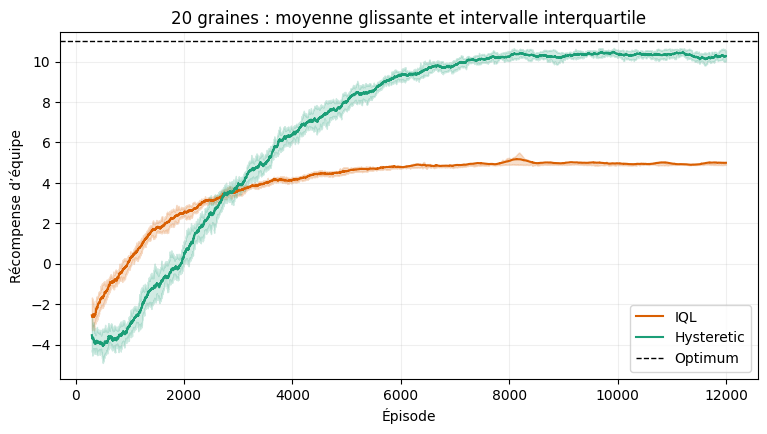

IQL        IQM=4.93, IC95%=[4.91, 4.95]
Hysteretic IQM=10.30, IC95%=[10.17, 10.37]


In [7]:
def moving_average(values, window=300):
    return np.convolve(values, np.ones(window) / window, mode="valid")

def iqm(values):
    values = np.sort(np.asarray(values, dtype=float))
    lo, hi = int(np.floor(.25 * len(values))), int(np.ceil(.75 * len(values)))
    return float(values[lo:hi].mean())

def bootstrap_iqm(values, seed=2026, n_boot=2000):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    stats = [iqm(rng.choice(values, len(values), replace=True)) for _ in range(n_boot)]
    return iqm(values), tuple(np.quantile(stats, [.025, .975]))

fig, ax = plt.subplots(figsize=(9, 4.5))
for label, runs, color in [("IQL", baseline_runs, "#d95f02"),
                           ("Hysteretic", hysteretic_runs, "#1b9e77")]:
    curves = np.stack([moving_average(run["rewards"]) for run in runs])
    x = np.arange(curves.shape[1]) + 300
    ax.plot(x, curves.mean(0), label=label, color=color)
    ax.fill_between(x, np.quantile(curves, .25, axis=0),
                    np.quantile(curves, .75, axis=0), color=color, alpha=.2)
ax.axhline(11, color="black", linestyle="--", linewidth=1, label="Optimum")
ax.set(xlabel="Épisode", ylabel="Récompense d’équipe",
       title="20 graines : moyenne glissante et intervalle interquartile")
ax.legend(); ax.grid(alpha=.2); plt.show()
for label, runs in [("IQL", baseline_runs), ("Hysteretic", hysteretic_runs)]:
    score, ci = bootstrap_iqm([run["tail_return"] for run in runs])
    print(f"{label:10s} IQM={score:.2f}, IC95%=[{ci[0]:.2f}, {ci[1]:.2f}]")

### Interprétation des courbes et des intervalles

Les intervalles bootstrap des IQM sont disjoints : `[4,91 ; 4,95]` pour IQL contre `[10,17 ; 10,37]` pour hysteretic Q-learning. Le contraste ne dépend donc pas d’une graine particulièrement favorable. L’IQM d’IQL reste proche de 5, cohérent avec les 19 graines dominées par `(C,C)`, tandis que 10,30 reste inférieur à l’optimum 11 à cause des explorations résiduelles imposées par $\varepsilon=0{,}02$.

Cette lecture combine trois preuves complémentaires : la dynamique temporelle des courbes, la destination de chaque graine et l’incertitude inter-graines. Aucune de ces trois vues ne suffit seule à attribuer le résultat au mécanisme étudié.

### Exercice 2 — Changer l’unité statistique

Pourquoi un bootstrap des épisodes, au lieu des graines, produirait-il un intervalle artificiellement étroit ? **Indice** : les épisodes successifs ne sont pas indépendants.

Formulez votre réponse en termes d'unité d'échantillonnage. Deux épisodes adjacents partagent les mêmes tables Q et presque le même $\varepsilon$ ; les considérer indépendants créerait une pseudo-réplication. Une extension plus ambitieuse pourrait employer un bootstrap par blocs temporels pour étudier la dynamique, mais elle ne remplacerait toujours pas les graines indépendantes pour comparer les méthodes.


In [8]:
explication_dependance = None  # TODO étudiant
print("Exercice 2 à compléter :", explication_dependance)

Exercice 2 à compléter : None


## 7. Ablation du pessimisme

Nous comparons $\alpha^-\in\{0{,}1;0{,}05;0{,}02;0{,}01\}$. Le réglage 0,05, insuffisant, est conservé pour éviter le cherry-picking.

### Lecture attendue

L'ablation teste une relation de dose plutôt qu'une opposition binaire. `0.10` reproduit exactement IQL ; `0.05` constitue le réglage d'échec annoncé ; `0.02` sonde une zone intermédiaire où plusieurs équilibres peuvent coexister ; `0.01` représente l'hysteresis forte. Chaque ligne est recalculée sur les mêmes vingt graines et rapporte à la fois la fréquence optimale et l'IQM avec son intervalle.

Cette grille évite deux erreurs de présentation : sélectionner après coup la seule valeur gagnante, ou conclure qu'il suffit d'imposer strictement $\alpha^-<\alpha^+$. Si `0.05` reste sous-optimal, l'inégalité seule n'est pas suffisante ; son amplitude est une composante empirique du remède.


In [9]:
ablation = {}
for alpha_negative in [0.1, 0.05, 0.02, 0.01]:
    runs = [run_climbing(seed, alpha_negative) for seed in SEEDS]
    optimal_rate = np.mean([run["dominant"] == (0, 0) for run in runs])
    score, ci = bootstrap_iqm([run["tail_return"] for run in runs])
    ablation[alpha_negative] = optimal_rate, score, ci
    print(f"alpha-={alpha_negative:.2f} | (A,A)={optimal_rate:5.0%} | "
          f"IQM={score:5.2f} | IC95%=[{ci[0]:.2f}, {ci[1]:.2f}]")

alpha-=0.10 | (A,A)=   0% | IQM= 4.93 | IC95%=[4.91, 4.95]


alpha-=0.05 | (A,A)=   0% | IQM= 4.96 | IC95%=[4.92, 5.05]


alpha-=0.02 | (A,A)=  60% | IQM= 9.09 | IC95%=[7.52, 10.30]


alpha-=0.01 | (A,A)= 100% | IQM=10.30 | IC95%=[10.17, 10.37]


### Interprétation de l’ablation

Un $\alpha^-$ trop proche de $\alpha^+$ échoue à protéger `A`; un optimisme plus fort bascule vers l’optimum. L’hystérésis atténue la pathologie sans supprimer la non-stationnarité ni le besoin d’explorer.

Le gradient observé soutient le mécanisme attendu lorsque la fréquence de `(A,A)` augmente à mesure que $\alpha^-$ diminue. Il ne justifie cependant pas de fixer $\alpha^-=0$ partout. Dans un autre jeu, une action peut produire occasionnellement une grande récompense mais avoir une espérance réellement mauvaise ; ignorer durablement ses erreurs négatives empêcherait la correction.

L'hysteresis est donc un compromis adapté à un régime coopératif où une partie des retours négatifs vient de coordinations transitoires. Des méthodes plus structurées peuvent aussi exploiter la valeur jointe, la communication, la centralisation à l'entraînement ou une exploration coordonnée. Ici, l'intérêt de l'hysteresis est d'isoler une modification minimale dans un protocole tabulaire contrôlé.


### Exercice 3 — Tester l’autre extrême

Ajoutez $\alpha^-=0$. Un agent qui n’apprend jamais des erreurs négatives peut-il rester optimiste face à une action réellement mauvaise dans un autre jeu ? Proposez une matrice contre-exemple.

Votre contre-exemple doit séparer « mauvaise coordination temporaire » et « action intrinsèquement risquée ». Par exemple, construisez une action dont le gain rare est positif mais dont la plupart des résultats coordonnés restent négatifs. Précisez ensuite quelle statistique vous compareriez pour montrer que $\alpha^-=0$ conserve à tort cette action.


In [10]:
resultat_alpha_zero = None  # TODO étudiant
print("Exercice 3 à compléter :", resultat_alpha_zero)

Exercice 3 à compléter : None


## 8. Conclusion

| Question | Réponse |
|---|---|
| Pourquoi IQL se trompe-t-il ? | Les mauvaises coordinations contaminent une action conjointement optimale. |
| Que change l’hystérésis ? | Elle apprend plus lentement des TD-errors négatives, sans modifier la récompense. |
| Pourquoi plusieurs graines ? | Une trajectoire unique ne mesure pas la probabilité de convergence. |
| Pourquoi IQM + bootstrap ? | Pour éviter le cherry-picking et quantifier l’incertitude. |
| Le remède est-il universel ? | Non : l’ablation conserve un réglage d’échec et l’optimisme extrême reste risqué. |

En MARL, une courbe de retour ne suffit pas : il faut mesurer **vers quel équilibre** chaque graine converge et relier ce résultat à la règle d’apprentissage.

## Limites et prolongements

- Le banc n'a qu'un état : il isole la sélection d'équilibre mais pas le crédit temporel.
- Les agents partagent une récompense et une architecture tabulaire ; les conclusions ne se transfèrent pas automatiquement aux jeux général-somme ni aux réseaux profonds.
- Vingt graines donnent une mesure honnête de la variabilité observée, pas une garantie sur toutes les initialisations.
- La classification par action conjointe dominante est adaptée à ce jeu discret. Un environnement continu demanderait un autre critère de convergence.

**Prolongement recommandé** : conserver le même protocole apparié et comparer hysteretic Q-learning à une exploration explicitement coordonnée. Si cette dernière récupère `(A,A)` sans asymétrie de taux, elle fournirait une intervention causale complémentaire sur l'autre maillon de la chaîne.

### Références

- Claus, C. et Boutilier, C. (1998), *The Dynamics of Reinforcement Learning in Cooperative Multiagent Systems*.
- Matignon, L., Laurent, G. J. et Le Fort-Piat, N. (2007), *Hysteretic Q-Learning: an Algorithm for Decentralized Reinforcement Learning in Cooperative Multi-Agent Teams*.
- Matignon, L., Laurent, G. J. et Le Fort-Piat, N. (2012), *Independent Reinforcement Learners in Cooperative Markov Games: a Survey Regarding Coordination Problems*.
- Hernandez-Leal, P., Kartal, B. et Taylor, M. E. (2019), *A Survey and Critique of Multiagent Deep Reinforcement Learning*.
